In [147]:
# import libraries
import warnings
import os

# import external libraries
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Tuple

# import sklearn libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Notebook configurations
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# set global constants
TRAIN_DATA_PATH = "data/train.csv" 
TEST_DATA_PATH = "data/test.csv"
TARGET_COLUMN = "SalePrice"  
RANDOM_STATE = 10
TEST_SIZE = 0.2

In [148]:

# function to load the dataset
def load_data(file_path_train: str, file_path_test: str) -> pd.DataFrame:
    """Loads raw dataset from a CSV file."""
    if not os.path.exists(file_path_train) and not os.path.exists(file_path_test):
        print(f"File not found at: {file_path_train} or {file_path_test}")
        raise FileNotFoundError(f"Missing input data: {file_path_train} or {file_path_test}")

    # load the data and print the shape of the data
    print(f"Loading data from {file_path_train}")
    df_train = pd.read_csv(file_path_train)
    df_test = pd.read_csv(file_path_test)
    print(f"Train Data shape: {df_train.shape}")
    print(f"Test Data Shape: {df_test.shape}")
    return df_train,df_test

try:
    # call the function
    df_train, df_test = load_data(TRAIN_DATA_PATH,TEST_DATA_PATH)

    # create a copy of the df 
    df_train_copy = pd.DataFrame.copy(df_train)
    df_test_copy = pd.DataFrame.copy(df_test)

except FileNotFoundError:
    print(f"Missing input data")




Loading data from data/train.csv
Train Data shape: (1460, 81)
Test Data Shape: (1459, 80)


In [149]:

# ===========================
# 1. Exploratory Data Analysis
# ===========================

def inspect_dataframe(df_train_copy: pd.DataFrame, df_test_copy: pd.DataFrame) -> None:
    """Features of the dataset"""
    
    for df in [df_train_copy,df_test_copy]:

        # print the missing values
        print("--- Missing Values ---")
        print(df.isnull().sum()[df.isnull().sum() > 0])

        # drop unwanted columns
        print("---Drop Columns---")
        #df.drop(columns=['Id','Alley','PoolQC','Fence','MiscFeature','MasVnrType'],inplace=True)

        # missing value imputation
        print("---Missing Value Imputation---")
        numerical_cols = [col for col in df if df[col].dtype!='object']
        categorical_cols = [col for col in df if df[col].dtype=='object']

        # median imputation
        for col in numerical_cols:
            df[col].fillna(df[col].median(),inplace=True)
        
        # mode imputation
        for col in categorical_cols:
            df[col].fillna(df[col].mode()[0],inplace=True)
        
        # print the missing values
        print("--- Missing Values ---")
        print(df.isnull().sum()[df.isnull().sum() > 0])
        
    return df_train_copy,df_test_copy,numerical_cols, categorical_cols

df_train_copy,df_test_copy,numerical_cols, categorical_cols=inspect_dataframe(df_train_copy,df_test_copy)

--- Missing Values ---
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
---Drop Columns---
---Missing Value Imputation---
--- Missing Values ---
Series([], dtype: int64)
--- Missing Values ---
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
Fir

In [150]:

# =============================
# 2. Split the data into training and testing
# =============================
def preprocess_pipeline(
    df_train_copy: pd.DataFrame, df_test_copy: pd.DataFrame, target_col: str, numerical_cols: np.ndarray, categorical_cols:np.ndarray
):
    """Encodes variables, and splits X and y."""

    # label encode both training and testing data
    for df in [df_train_copy,df_test_copy]:
        # perform label encoding on the categorical cols
        label_encoder = LabelEncoder()
        for x in categorical_cols:
            df[x] = label_encoder.fit_transform(df[x])

            le_name_mapping = dict(zip(label_encoder.classes_,label_encoder.transform(label_encoder.classes_)))
            print("Feature : ",x)
            print("Mapping : ",le_name_mapping)  
    
    return label_encoder

# call the function
label_encoder = preprocess_pipeline(df_train_copy,df_test_copy, TARGET_COLUMN, numerical_cols, categorical_cols)


Feature :  MSZoning
Mapping :  {'C (all)': np.int64(0), 'FV': np.int64(1), 'RH': np.int64(2), 'RL': np.int64(3), 'RM': np.int64(4)}
Feature :  Street
Mapping :  {'Grvl': np.int64(0), 'Pave': np.int64(1)}
Feature :  Alley
Mapping :  {'Grvl': np.int64(0), 'Pave': np.int64(1)}
Feature :  LotShape
Mapping :  {'IR1': np.int64(0), 'IR2': np.int64(1), 'IR3': np.int64(2), 'Reg': np.int64(3)}
Feature :  LandContour
Mapping :  {'Bnk': np.int64(0), 'HLS': np.int64(1), 'Low': np.int64(2), 'Lvl': np.int64(3)}
Feature :  Utilities
Mapping :  {'AllPub': np.int64(0), 'NoSeWa': np.int64(1)}
Feature :  LotConfig
Mapping :  {'Corner': np.int64(0), 'CulDSac': np.int64(1), 'FR2': np.int64(2), 'FR3': np.int64(3), 'Inside': np.int64(4)}
Feature :  LandSlope
Mapping :  {'Gtl': np.int64(0), 'Mod': np.int64(1), 'Sev': np.int64(2)}
Feature :  Neighborhood
Mapping :  {'Blmngtn': np.int64(0), 'Blueste': np.int64(1), 'BrDale': np.int64(2), 'BrkSide': np.int64(3), 'ClearCr': np.int64(4), 'CollgCr': np.int64(5), 'Cra

In [151]:
def train_and_test() -> Tuple[np.ndarray, np.ndarray]:
    """Splits training data for validation, scales correctly, and trains the model."""
    
    # initialise standard scaler
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()

    # Isolate raw training features and target
    Y_raw = df_train_copy[[TARGET_COLUMN]] 
    X_raw = df_train_copy.drop(columns=[TARGET_COLUMN])    

    # Split the data into training and testing
    X_train_raw, X_val_raw, Y_train_raw, Y_val_raw = train_test_split(
        X_raw, Y_raw, test_size=0.2, random_state=42
    )

    # scale Y data
    X_train = scaler_X.fit_transform(X_train_raw)
    X_val = scaler_X.transform(X_val_raw)    
    
    # scale X data
    Y_train = scaler_Y.fit_transform(Y_train_raw)
    Y_val = scaler_Y.transform(Y_val_raw)    

    # Train the model
    linear_model = LinearRegression()
    linear_model.fit(X_train, Y_train)

    # print the length of X_train
    print("Length of the X_train : ", len(X_train))
    print("---Train and Test the model---")
    
    # Predict on your local validation set (X_val)
    Y_pred_scaled = linear_model.predict(X_val)
    
    # print the intercept and coefficient
    print("Intercept: ", linear_model.intercept_)
    print("Coefficient: ", linear_model.coef_)

    # Inverse transform predictions back to original price scale (e.g., Dollars)
    Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
    Y_val_original = scaler_Y.inverse_transform(Y_val)

    # Flatten arrays back to 1D vectors for cleaner downstream use
    return Y_val_original.flatten(), Y_pred.flatten(),X_raw,Y_raw, linear_model, scaler_X,scaler_Y

# Call the function
Y_test, Y_pred,X_raw,Y_raw, linear_model, scaler_X, scaler_Y = train_and_test()


Length of the X_train :  1168
---Train and Test the model---
Intercept:  [9.01877972e-16]
Coefficient:  [[-1.07781546e-02 -6.58531942e-02 -2.42010801e-02 -7.29419286e-02
   4.89093003e-02  1.64310751e-02 -6.23971425e-03 -2.03907965e-02
   2.15308286e-02 -1.86021695e-02 -1.57838049e-04  3.83410089e-02
   3.07062369e-02 -4.36450185e-03 -3.59901449e-02 -3.89454371e-02
  -2.61554061e-02  1.85222896e-01  7.62013169e-02  7.40767584e-02
   1.66624179e-02  2.39185298e-02  4.29042409e-02 -6.35173209e-02
   4.03304797e-02  1.29915946e-02  4.90936236e-02 -7.74791286e-02
   1.09518302e-03  6.53040895e-03 -1.10642630e-01  2.95005261e-02
  -5.09584418e-02 -8.27001804e-03  2.77144769e-02  1.62524656e-02
   1.48375860e-02 -1.67916951e-02  1.71900777e-02 -1.48325521e-03
  -4.06179483e-03  2.41593364e-03 -6.82746391e-03  1.08709609e-01
   1.02851633e-01 -1.70882680e-02  1.64802069e-01  5.00916018e-02
  -1.31219828e-02  1.23070346e-02 -6.21761563e-03 -2.11058952e-02
  -3.95809009e-02 -9.55012878e-02  8.5

In [152]:

def model_evaluation(Y_test: np.array ,Y_pred: np.array, X_raw: np.array, Y_raw: np.array):
    """Evaluate the model based on r2, RMSE and Adjusted r2 values"""
    
    #evaluation metric - R^2
    r2 = r2_score(Y_test,Y_pred)
    print("R2 value: ",r2)

    # evaluation metric - RMSE
    rmse = np.sqrt(mean_squared_error (Y_test, Y_pred))
    print("RMSE Value: ",rmse)

    # evaluation metric - adj R^2
    adjusted_r_squared = 1 - (1-r2) * (len(Y_raw) - 1) / (len(Y_raw)-X_raw.shape[1]-1)
    print("Adjusted R^2 Value: ",adjusted_r_squared)

    # check RMSE values
    print("Minimum of Y_test: ",min(Y_test))
    print("Maximum of Y_test: ",max(Y_test))

model_evaluation(Y_test,Y_pred,X_raw,Y_raw)

R2 value:  0.8371369170530626
RMSE Value:  35344.207068644
Adjusted R^2 Value:  0.8276887324005934
Minimum of Y_test:  35311.0
Maximum of Y_test:  755000.0


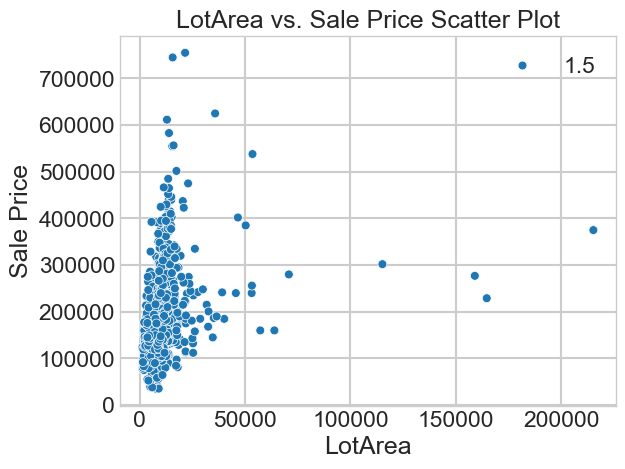

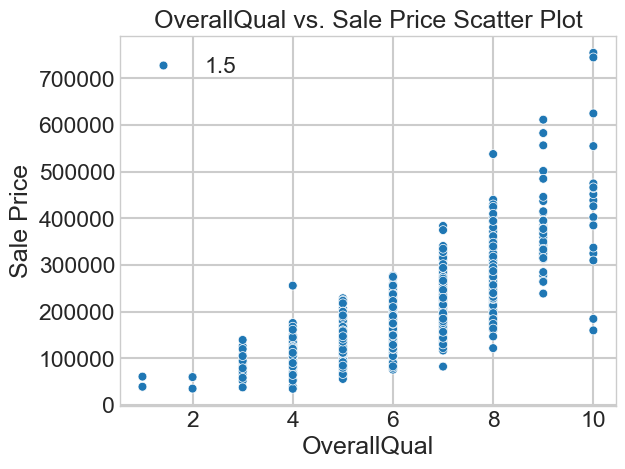

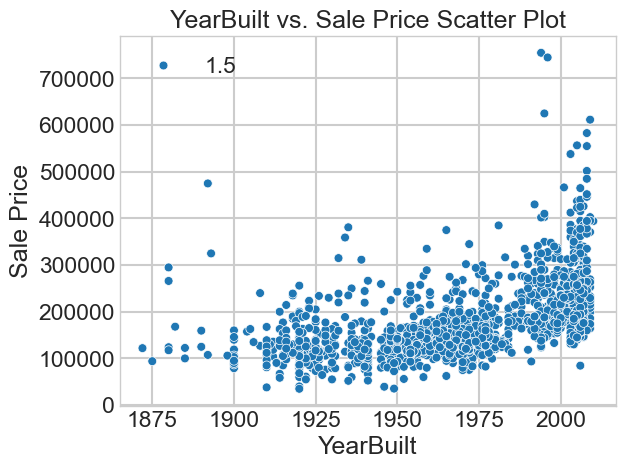

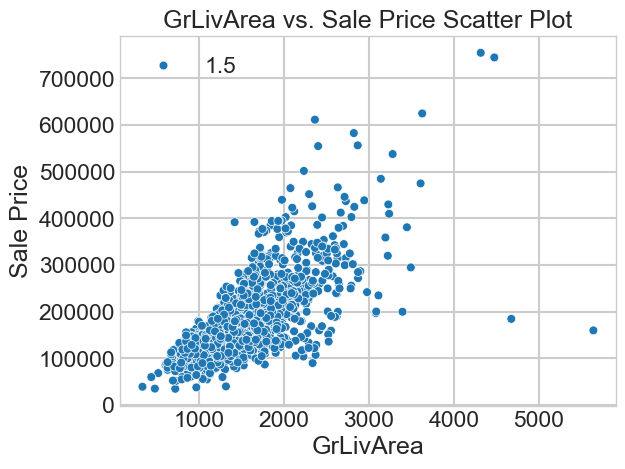

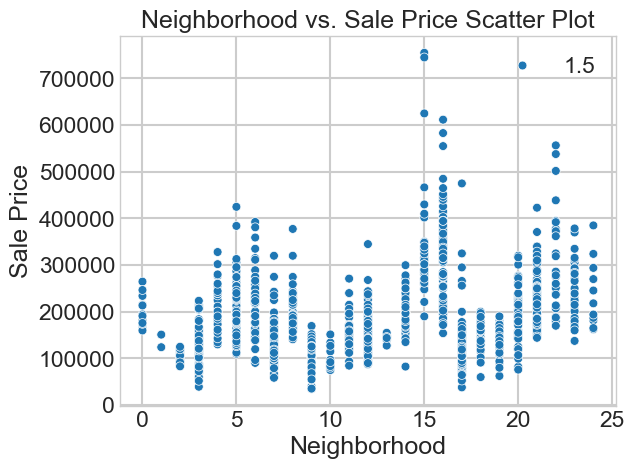

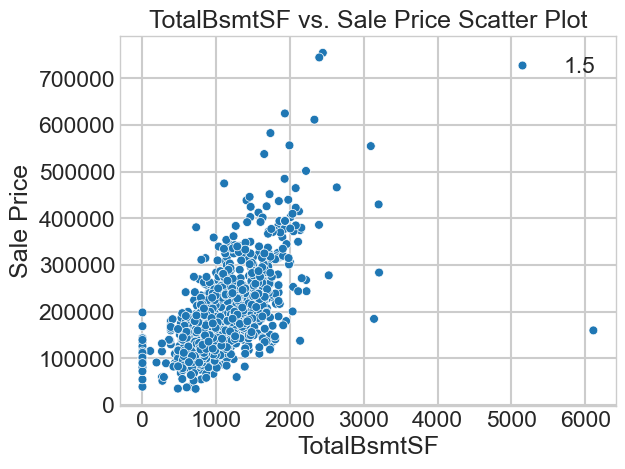

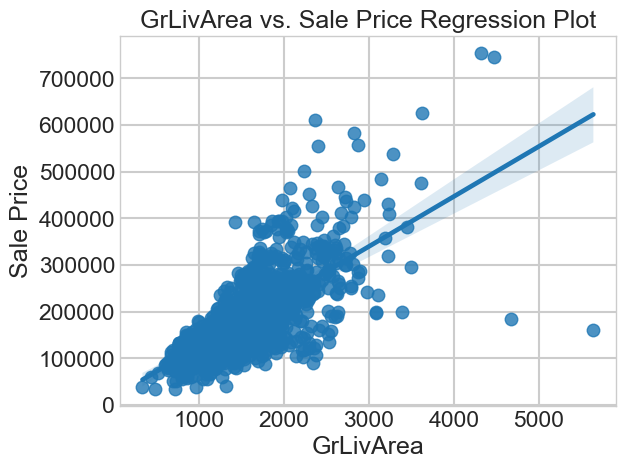

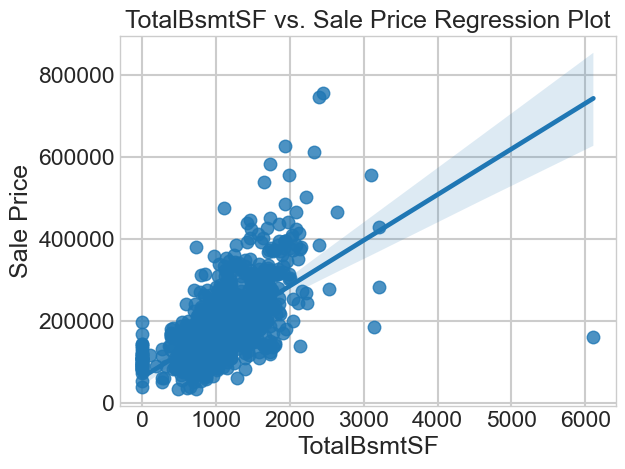

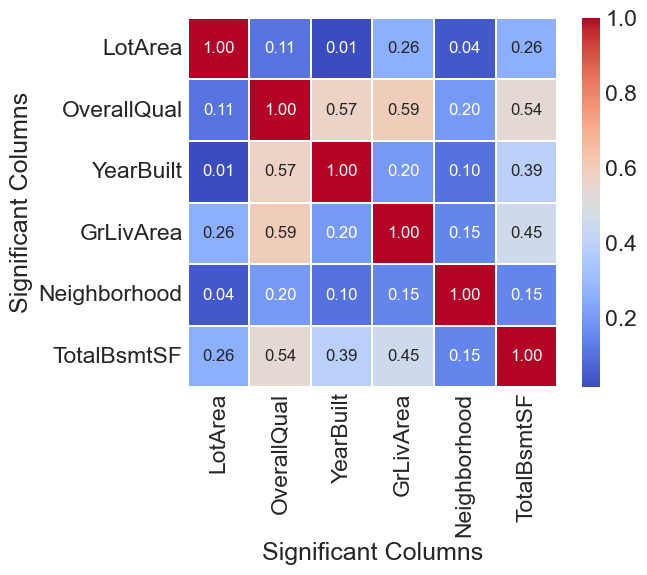

In [153]:
def visualizations(numerical_cols)->None:
    
    # create a list of significant columns
    significant_columns = ['LotArea', 'OverallQual','YearBuilt','GrLivArea','Neighborhood','TotalBsmtSF']

    # Feature vs. Price Scatter Plot
    for col in significant_columns:
        plt.Figure(figsize=(8,6))
        sns.scatterplot(
            data=df_train_copy,
            x=col,
            y='SalePrice',
            size=1.5,
            markers=True
        )
        plt.title(f"{col} vs. Sale Price Scatter Plot")
        plt.xlabel(col)
        plt.ylabel('Sale Price')
        plt.show()
    
    # Regression PLots
    for col in ['GrLivArea','TotalBsmtSF']:
        plt.Figure(figsize=(8,6))
        sns.regplot(
            data=df_train_copy,
            x=col,
            y='SalePrice',
            scatter=True
        )
        plt.title(f"{col} vs. Sale Price Regression Plot")
        plt.xlabel(col)
        plt.ylabel('Sale Price')
        plt.show()

    # Correlation Heatmap
    numerical_df = df_train_copy[['LotArea', 'OverallQual','YearBuilt','GrLivArea','Neighborhood','TotalBsmtSF']]
    numerical_corr = numerical_df.corr()
    plt.Figure(figsize=(8,6))
    sns.heatmap(
        numerical_corr,
        cmap='coolwarm',
        linewidths=1.2,
        fmt=".2f",
        square=True,
        annot=True,
        annot_kws={"size": 12}
    )
    sns.set_context("talk")
    plt.xlabel("Significant Columns")
    plt.ylabel("Significant Columns")
    plt.show()
    
visualizations(numerical_cols)

In [154]:
def model_dump(linear_model,scaler_X,scaler_Y) -> None:
    """Dump The Model and Scaler"""

    # dump the scaler X
    with open('scaler_X.pkl','wb') as scaler_X_file:
        joblib.dump(scaler_X,scaler_X_file)
    
    # dump the scaler Y
    with open('scaler_Y.pkl','wb') as scaler_Y_file:
        joblib.dump(scaler_Y,scaler_Y_file)
    
    # dump the model
    with open('model.pkl','wb') as model_file:
        joblib.dump(linear_model,model_file)
    
    # dump the label encoder
    with open('label_encoder.pkl','wb') as label_encoder_file:
        joblib.dump(label_encoder,label_encoder_file)

model_dump(linear_model,scaler_X,scaler_Y)